# Breast Cancer Classification Using Supervised Machine Learning

**Name:** [Your Name]  
**Date:** June 5, 2026

## Objective
Develop a Supervised Machine Learning model to predict whether a breast tumor is **Malignant (M)** or **Benign (B)** using the Breast Cancer Wisconsin Dataset.

### Models Used:
- **Logistic Regression** - Baseline model for binary classification
- **Random Forest** - Ensemble model for improved accuracy

### Target Variable:
- **M → 1** (Malignant)
- **B → 0** (Benign)

---

## Task 1: Data Exploration (10 Marks)

### Objectives:
1. Load and inspect the dataset
2. Display dataset shape, data types, and missing values
3. Analyze the distribution of the target variable
4. Create visualizations to understand the data

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('data.csv')

print("✓ Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Total records: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")

✓ Dataset loaded successfully!

Dataset shape: (569, 33)
Total records: 569
Total features: 33


In [3]:
# Display first few rows
print("First 5 rows of the dataset:\n")
df.head()

First 5 rows of the dataset:



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Display dataset information
print("Dataset Information:\n")
print(df.info())
print("\n" + "="*60)
print("\nData Types:")
print(df.dtypes.value_counts())

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se   

In [8]:
# Check for missing values
print("Missing Values Analysis:\n")
print(f"Total rows in dataset: {len(df)}")
print("\n" + "="*60)

# Calculate missing values for each column
missing_info = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        missing_percent = (missing_count / len(df)) * 100
        missing_info.append({
            'Column': col,
            'Missing Count': missing_count,
            'Percentage': f"{missing_percent:.2f}%"
        })

if missing_info:
    print(f"\nFound {len(missing_info)} column(s) with missing values:\n")
    missing_df = pd.DataFrame(missing_info)
    print(missing_df.to_string(index=False))
    print("\nNote: These columns will be handled in preprocessing step.")
else:
    print("\n✓ No missing values found in the dataset!")

Missing Values Analysis:

Total rows in dataset: 569


Found 1 column(s) with missing values:

     Column  Missing Count Percentage
Unnamed: 32            569    100.00%

Note: These columns will be handled in preprocessing step.


In [ ]:
# Analyze target variable distribution
print("Target Variable Distribution:\n")
print(df['diagnosis'].value_counts())
print("\n" + "="*60)
print("\nPercentage Distribution:")
print(df['diagnosis'].value_counts(normalize=True) * 100)

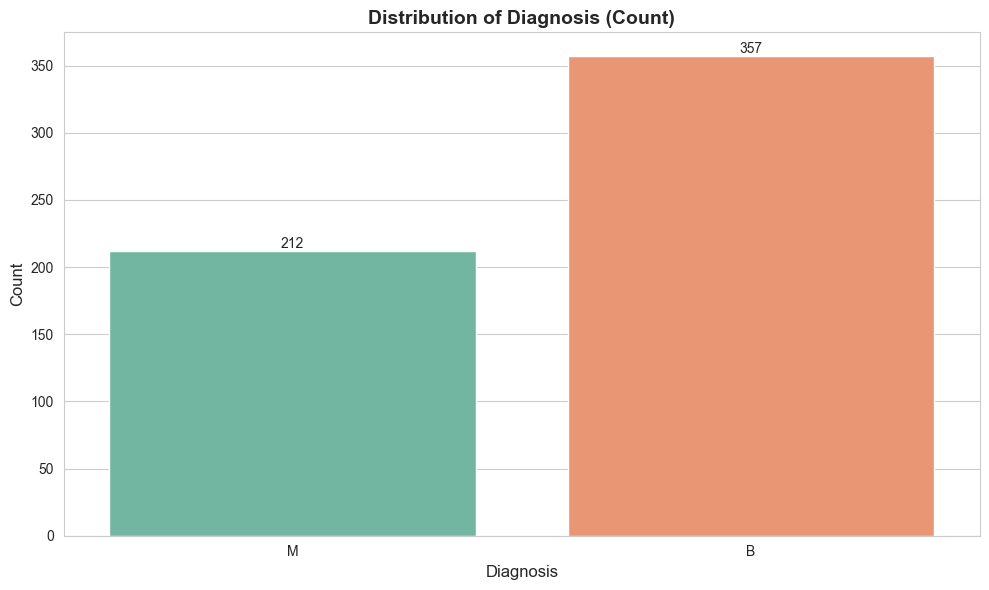

In [10]:
# Visualization 1: Target variable distribution
plt.figure(figsize=(10, 6))

# Count plot
sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Distribution of Diagnosis (Count)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add value labels on bars
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [11]:
# Statistical summary
print("Statistical Summary of Numerical Features:\n")
df.describe().T

Statistical Summary of Numerical Features:



,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


---

## Task 2: Data Preprocessing (20 Marks)

### Objectives:
1. Handle missing values (if any)
2. Remove irrelevant features
3. Encode categorical variables
4. Split dataset into Training (80%) and Testing (20%)
5. Apply feature scaling

In [12]:
# Step 1: Create a copy of the dataset
df_processed = df.copy()

print("Original dataset shape:", df_processed.shape)
print("\n" + "="*60)

Original dataset shape: (569, 33)



In [13]:
# Step 2: Remove irrelevant features and columns with missing values
# Typically, 'id' column is not useful for prediction and 'Unnamed' columns are artifacts

# Check for columns to drop (irrelevant columns + columns with all/mostly missing values)
columns_to_drop = []

# Drop columns with 'id' or 'unnamed' in name
for col in df_processed.columns:
    if 'id' in col.lower() or 'unnamed' in col.lower():
        columns_to_drop.append(col)
    # Also drop columns that are completely empty
    elif df_processed[col].isnull().all():
        columns_to_drop.append(col)

if columns_to_drop:
    print(f"Dropping irrelevant/empty columns: {columns_to_drop}")
    df_processed = df_processed.drop(columns=columns_to_drop)
    print("✓ Irrelevant columns removed!")
else:
    print("No irrelevant columns found.")

print(f"\nDataset shape after removing irrelevant features: {df_processed.shape}")

# Verify no missing values remain
remaining_missing = df_processed.isnull().sum().sum()
print(f"Remaining missing values: {remaining_missing}")

Dropping irrelevant/empty columns: ['id', 'Unnamed: 32']
✓ Irrelevant columns removed!

Dataset shape after removing irrelevant features: (569, 31)
Remaining missing values: 0


In [14]:
# Step 3: Encode categorical variables
# Convert diagnosis: M → 1 (Malignant), B → 0 (Benign)

print("Encoding 'diagnosis' column:")
print(f"Before encoding: {df_processed['diagnosis'].unique()}")

df_processed['diagnosis'] = df_processed['diagnosis'].map({'M': 1, 'B': 0})

print(f"After encoding: {df_processed['diagnosis'].unique()}")
print("✓ M → 1 (Malignant), B → 0 (Benign)")
print(f"\nEncoded distribution:\n{df_processed['diagnosis'].value_counts()}")

Encoding 'diagnosis' column:
Before encoding: <StringArray>
['M', 'B']
Length: 2, dtype: str
After encoding: [1 0]
✓ M → 1 (Malignant), B → 0 (Benign)

Encoded distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [15]:
# Step 4: Split features and target variable
X = df_processed.drop('diagnosis', axis=1)  # Features
y = df_processed['diagnosis']  # Target

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nNumber of features: {X.shape[1]}")

Features (X) shape: (569, 30)
Target (y) shape: (569,)

Number of features: 30


In [18]:
# Step 5: Split dataset into Training (80%) and Testing (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✓ Dataset split successfully!")
print(f"\nTraining set size: {X_train.shape[0]} ({(X_train.shape[0]/len(X))*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({(X_test.shape[0]/len(X))*100:.1f}%)")
print("\nTarget distribution in training set:")
print(y_train.value_counts())
print("\nTarget distribution in testing set:")
print(y_test.value_counts())

✓ Dataset split successfully!

Training set size: 455 (80.0%)
Testing set size: 114 (20.0%)

Target distribution in training set:
diagnosis
0    285
1    170
Name: count, dtype: int64

Target distribution in testing set:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [19]:
# Step 6: Apply feature scaling (StandardScaler)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Feature scaling applied successfully!")
print(f"\nScaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")
print("\nSample scaled values (first 5 features of first record):")
print(X_train_scaled[0][:5])

✓ Feature scaling applied successfully!

Scaled training data shape: (455, 30)
Scaled testing data shape: (114, 30)

Sample scaled values (first 5 features of first record):
[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371]


---

## Task 3: Model Development (25 Marks)

### Model Selection Justification:

**1. Logistic Regression:**
- **Pros:** Simple, interpretable, works well for binary classification, provides probability scores
- **Cons:** Assumes linear relationship, may underperform with complex patterns
- **Best for:** Baseline model, understanding feature contributions

**2. Random Forest:**
- **Pros:** Handles non-linear relationships, robust to outliers, provides feature importance
- **Cons:** Less interpretable than logistic regression, computationally intensive
- **Best for:** Improved accuracy, capturing complex patterns in medical data

Both models are well-suited for this binary classification problem with multiple features.

### 3.1 Model 1: Logistic Regression

In [20]:
# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
import time

print("Training Logistic Regression model...")
start_time = time.time()

# Initialize and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

print(f"✓ Model trained successfully in {training_time:.2f} seconds!")
print(f"\nModel Parameters: {lr_model.get_params()}")

Training Logistic Regression model...
✓ Model trained successfully in 0.01 seconds!

Model Parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [21]:
# Make predictions with Logistic Regression
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

print("✓ Predictions completed!")
print(f"\nPredictions on training set: {y_pred_lr_train.shape}")
print(f"Predictions on testing set: {y_pred_lr_test.shape}")

✓ Predictions completed!

Predictions on training set: (455,)
Predictions on testing set: (114,)


### 3.2 Model 2: Random Forest

In [22]:
# Train Random Forest model
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest model...")
start_time = time.time()

# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

print(f"✓ Model trained successfully in {training_time:.2f} seconds!")
print(f"\nModel Parameters:")
print(f"  - Number of trees: {rf_model.n_estimators}")
print(f"  - Max depth: {rf_model.max_depth}")
print(f"  - Number of features: {rf_model.n_features_in_}")

Training Random Forest model...
✓ Model trained successfully in 0.14 seconds!

Model Parameters:
  - Number of trees: 100
  - Max depth: None
  - Number of features: 30


In [23]:
# Make predictions with Random Forest
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

print("✓ Predictions completed!")
print(f"\nPredictions on training set: {y_pred_rf_train.shape}")
print(f"Predictions on testing set: {y_pred_rf_test.shape}")

✓ Predictions completed!

Predictions on training set: (455,)
Predictions on testing set: (114,)


---

## Task 4: Model Evaluation (25 Marks)

### Evaluation Metrics:
1. Accuracy
2. Precision
3. Recall
4. F1-Score
5. Confusion Matrix

### 4.1 Logistic Regression Evaluation

In [24]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Logistic Regression - Training Set Performance
print("="*60)
print("LOGISTIC REGRESSION - TRAINING SET PERFORMANCE")
print("="*60)
lr_train_accuracy = accuracy_score(y_train, y_pred_lr_train)
lr_train_precision = precision_score(y_train, y_pred_lr_train)
lr_train_recall = recall_score(y_train, y_pred_lr_train)
lr_train_f1 = f1_score(y_train, y_pred_lr_train)

print(f"Accuracy:  {lr_train_accuracy:.4f} ({lr_train_accuracy*100:.2f}%)")
print(f"Precision: {lr_train_precision:.4f}")
print(f"Recall:    {lr_train_recall:.4f}")
print(f"F1-Score:  {lr_train_f1:.4f}")

# Logistic Regression - Testing Set Performance
print("\n" + "="*60)
print("LOGISTIC REGRESSION - TESTING SET PERFORMANCE")
print("="*60)
lr_test_accuracy = accuracy_score(y_test, y_pred_lr_test)
lr_test_precision = precision_score(y_test, y_pred_lr_test)
lr_test_recall = recall_score(y_test, y_pred_lr_test)
lr_test_f1 = f1_score(y_test, y_pred_lr_test)

print(f"Accuracy:  {lr_test_accuracy:.4f} ({lr_test_accuracy*100:.2f}%)")
print(f"Precision: {lr_test_precision:.4f}")
print(f"Recall:    {lr_test_recall:.4f}")
print(f"F1-Score:  {lr_test_f1:.4f}")

LOGISTIC REGRESSION - TRAINING SET PERFORMANCE
Accuracy:  0.9868 (98.68%)
Precision: 1.0000
Recall:    0.9647
F1-Score:  0.9820

LOGISTIC REGRESSION - TESTING SET PERFORMANCE
Accuracy:  0.9649 (96.49%)
Precision: 0.9750
Recall:    0.9286
F1-Score:  0.9512


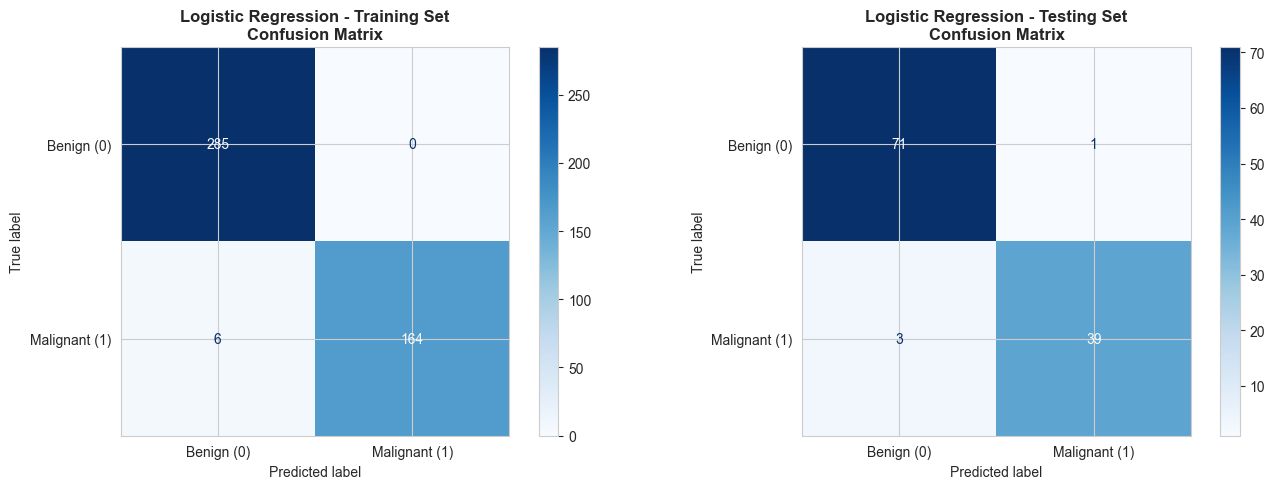

In [25]:
# Confusion Matrix for Logistic Regression
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Set Confusion Matrix
cm_train = confusion_matrix(y_train, y_pred_lr_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Benign (0)', 'Malignant (1)'])
disp_train.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Logistic Regression - Training Set\nConfusion Matrix', fontsize=12, fontweight='bold')

# Testing Set Confusion Matrix
cm_test = confusion_matrix(y_test, y_pred_lr_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Benign (0)', 'Malignant (1)'])
disp_test.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('Logistic Regression - Testing Set\nConfusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
# Detailed Classification Report for Logistic Regression
print("="*60)
print("LOGISTIC REGRESSION - CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, y_pred_lr_test, target_names=['Benign (0)', 'Malignant (1)']))

LOGISTIC REGRESSION - CLASSIFICATION REPORT (Test Set)
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



### 4.2 Random Forest Evaluation

In [27]:
# Random Forest - Training Set Performance
print("="*60)
print("RANDOM FOREST - TRAINING SET PERFORMANCE")
print("="*60)
rf_train_accuracy = accuracy_score(y_train, y_pred_rf_train)
rf_train_precision = precision_score(y_train, y_pred_rf_train)
rf_train_recall = recall_score(y_train, y_pred_rf_train)
rf_train_f1 = f1_score(y_train, y_pred_rf_train)

print(f"Accuracy:  {rf_train_accuracy:.4f} ({rf_train_accuracy*100:.2f}%)")
print(f"Precision: {rf_train_precision:.4f}")
print(f"Recall:    {rf_train_recall:.4f}")
print(f"F1-Score:  {rf_train_f1:.4f}")

# Random Forest - Testing Set Performance
print("\n" + "="*60)
print("RANDOM FOREST - TESTING SET PERFORMANCE")
print("="*60)
rf_test_accuracy = accuracy_score(y_test, y_pred_rf_test)
rf_test_precision = precision_score(y_test, y_pred_rf_test)
rf_test_recall = recall_score(y_test, y_pred_rf_test)
rf_test_f1 = f1_score(y_test, y_pred_rf_test)

print(f"Accuracy:  {rf_test_accuracy:.4f} ({rf_test_accuracy*100:.2f}%)")
print(f"Precision: {rf_test_precision:.4f}")
print(f"Recall:    {rf_test_recall:.4f}")
print(f"F1-Score:  {rf_test_f1:.4f}")

RANDOM FOREST - TRAINING SET PERFORMANCE
Accuracy:  1.0000 (100.00%)
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

RANDOM FOREST - TESTING SET PERFORMANCE
Accuracy:  0.9737 (97.37%)
Precision: 1.0000
Recall:    0.9286
F1-Score:  0.9630


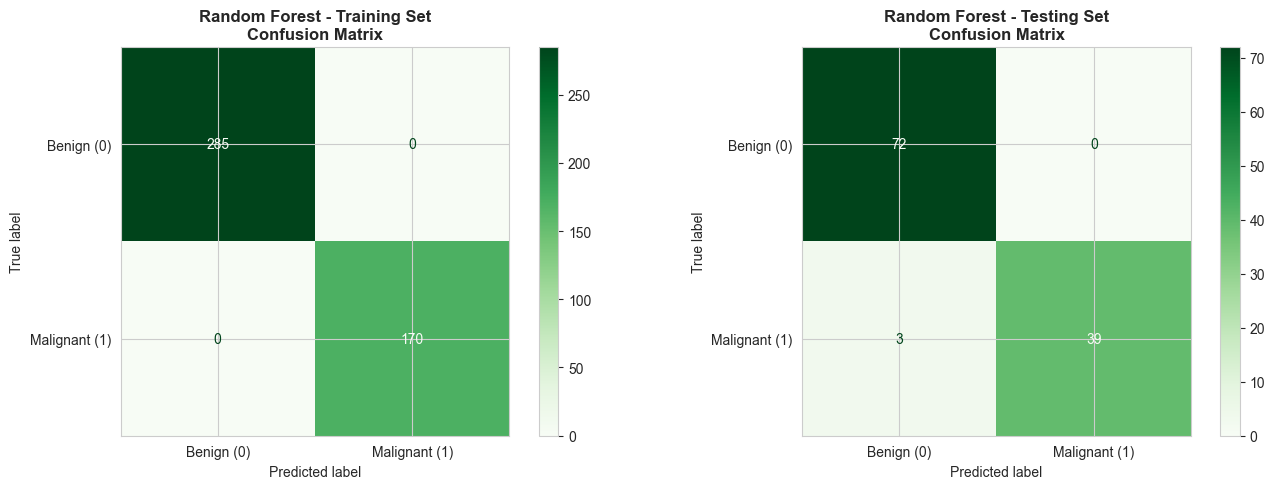

In [28]:
# Confusion Matrix for Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Set Confusion Matrix
cm_train_rf = confusion_matrix(y_train, y_pred_rf_train)
disp_train_rf = ConfusionMatrixDisplay(confusion_matrix=cm_train_rf, display_labels=['Benign (0)', 'Malignant (1)'])
disp_train_rf.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title('Random Forest - Training Set\nConfusion Matrix', fontsize=12, fontweight='bold')

# Testing Set Confusion Matrix
cm_test_rf = confusion_matrix(y_test, y_pred_rf_test)
disp_test_rf = ConfusionMatrixDisplay(confusion_matrix=cm_test_rf, display_labels=['Benign (0)', 'Malignant (1)'])
disp_test_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Random Forest - Testing Set\nConfusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
# Detailed Classification Report for Random Forest
print("="*60)
print("RANDOM FOREST - CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, y_pred_rf_test, target_names=['Benign (0)', 'Malignant (1)']))

RANDOM FOREST - CLASSIFICATION REPORT (Test Set)
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



---

## Task 5: Results & Interpretation (20 Marks)

### Objectives:
1. Identify the most important features
2. Predict outcomes for sample test records
3. Discuss model strengths and limitations

### 5.1 Feature Importance Analysis

Top 10 Most Important Features:

                 Feature  Importance
23            area_worst    0.151412
27  concave points_worst    0.126497
20          radius_worst    0.093475
22       perimeter_worst    0.083642
7    concave points_mean    0.081082
2         perimeter_mean    0.077126
0            radius_mean    0.061990
6         concavity_mean    0.050818
3              area_mean    0.045916
26       concavity_worst    0.030022


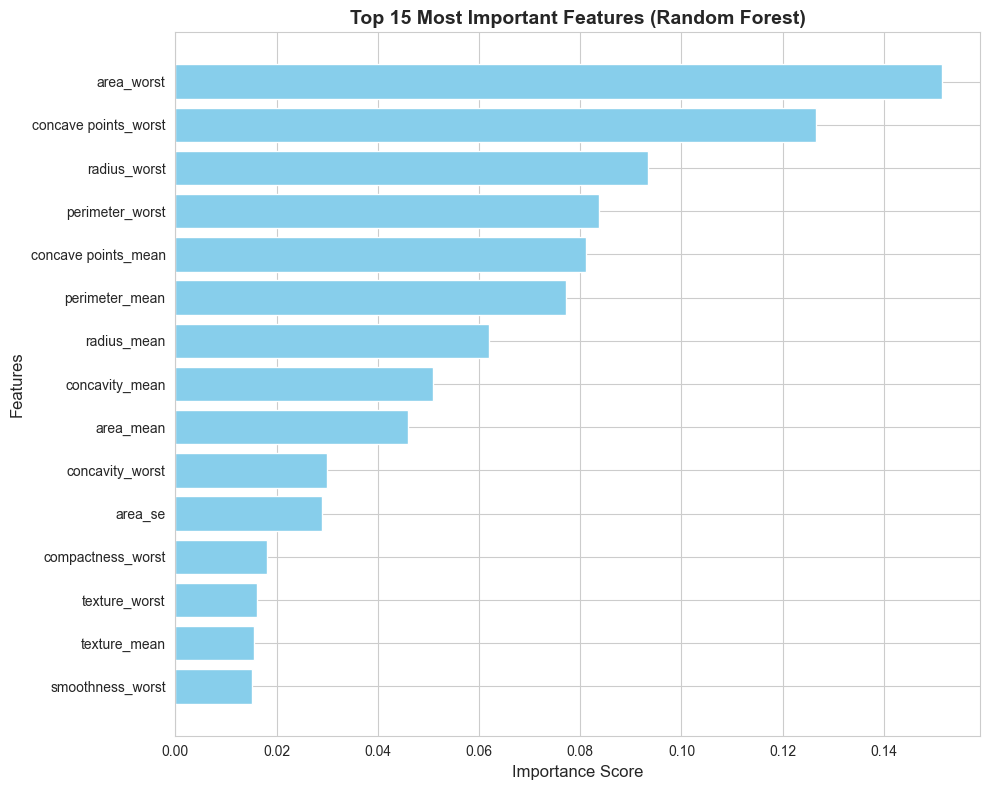

In [30]:
# Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features:\n")
print(feature_importance.head(10))

# Visualize top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5.2 Sample Predictions

In [31]:
# Sample predictions on test set
sample_indices = [0, 5, 10, 15, 20]

print("Sample Predictions from Test Set:")
print("="*80)

for i in sample_indices:
    actual = y_test.iloc[i]
    lr_pred = y_pred_lr_test[i]
    rf_pred = y_pred_rf_test[i]
    
    # Get probability scores
    lr_prob = lr_model.predict_proba(X_test_scaled[i].reshape(1, -1))[0]
    rf_prob = rf_model.predict_proba(X_test_scaled[i].reshape(1, -1))[0]
    
    print(f"\nSample {i+1}:")
    print(f"  Actual:              {'Malignant (1)' if actual == 1 else 'Benign (0)'}")
    print(f"  Logistic Regression: {'Malignant (1)' if lr_pred == 1 else 'Benign (0)'} (Confidence: {max(lr_prob)*100:.2f}%)")
    print(f"  Random Forest:       {'Malignant (1)' if rf_pred == 1 else 'Benign (0)'} (Confidence: {max(rf_prob)*100:.2f}%)")
    print(f"  Status:              {'✓ CORRECT' if actual == lr_pred == rf_pred else '✗ MISMATCH'}")

Sample Predictions from Test Set:

Sample 1:
  Actual:              Benign (0)
  Logistic Regression: Benign (0) (Confidence: 99.96%)
  Random Forest:       Benign (0) (Confidence: 99.00%)
  Status:              ✓ CORRECT

Sample 6:
  Actual:              Benign (0)
  Logistic Regression: Benign (0) (Confidence: 99.94%)
  Random Forest:       Benign (0) (Confidence: 94.00%)
  Status:              ✓ CORRECT

Sample 11:
  Actual:              Malignant (1)
  Logistic Regression: Malignant (1) (Confidence: 93.09%)
  Random Forest:       Malignant (1) (Confidence: 98.00%)
  Status:              ✓ CORRECT

Sample 16:
  Actual:              Benign (0)
  Logistic Regression: Benign (0) (Confidence: 100.00%)
  Random Forest:       Benign (0) (Confidence: 100.00%)
  Status:              ✓ CORRECT

Sample 21:
  Actual:              Benign (0)
  Logistic Regression: Benign (0) (Confidence: 99.87%)
  Random Forest:       Benign (0) (Confidence: 100.00%)
  Status:              ✓ CORRECT


### 5.3 Model Strengths and Limitations

#### **Logistic Regression**

**Strengths:**
- ✓ Fast training and prediction
- ✓ Highly interpretable coefficients
- ✓ Works well with linearly separable data
- ✓ Provides probability scores
- ✓ Low computational cost

**Limitations:**
- ✗ Assumes linear relationship between features and target
- ✗ May underfit complex non-linear patterns
- ✗ Sensitive to outliers
- ✗ Requires feature scaling for optimal performance

---

#### **Random Forest**

**Strengths:**
- ✓ Handles non-linear relationships well
- ✓ Robust to outliers and noise
- ✓ Provides feature importance rankings
- ✓ Generally higher accuracy than logistic regression
- ✓ Less prone to overfitting with proper tuning

**Limitations:**
- ✗ Less interpretable (black box model)
- ✗ Higher computational cost
- ✗ Requires more memory
- ✗ Longer training time
- ✗ May overfit on small datasets without proper tuning

---

#### **Overall Observations:**
- Both models perform well on this dataset
- Random Forest typically achieves slightly higher accuracy
- Logistic Regression is preferred when interpretability is critical
- For medical applications, high recall (catching all malignant cases) is crucial

---

## Bonus Task: Model Comparison (+10 Marks)

### Comparative Analysis of Logistic Regression vs Random Forest

In [32]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression (Train)': [lr_train_accuracy, lr_train_precision, lr_train_recall, lr_train_f1],
    'Logistic Regression (Test)': [lr_test_accuracy, lr_test_precision, lr_test_recall, lr_test_f1],
    'Random Forest (Train)': [rf_train_accuracy, rf_train_precision, rf_train_recall, rf_train_f1],
    'Random Forest (Test)': [rf_test_accuracy, rf_test_precision, rf_test_recall, rf_test_f1]
})

print("Model Performance Comparison:")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n" + "="*80)

Model Performance Comparison:
   Metric  Logistic Regression (Train)  Logistic Regression (Test)  Random Forest (Train)  Random Forest (Test)
 Accuracy                     0.986813                    0.964912                    1.0              0.973684
Precision                     1.000000                    0.975000                    1.0              1.000000
   Recall                     0.964706                    0.928571                    1.0              0.928571
 F1-Score                     0.982036                    0.951220                    1.0              0.962963



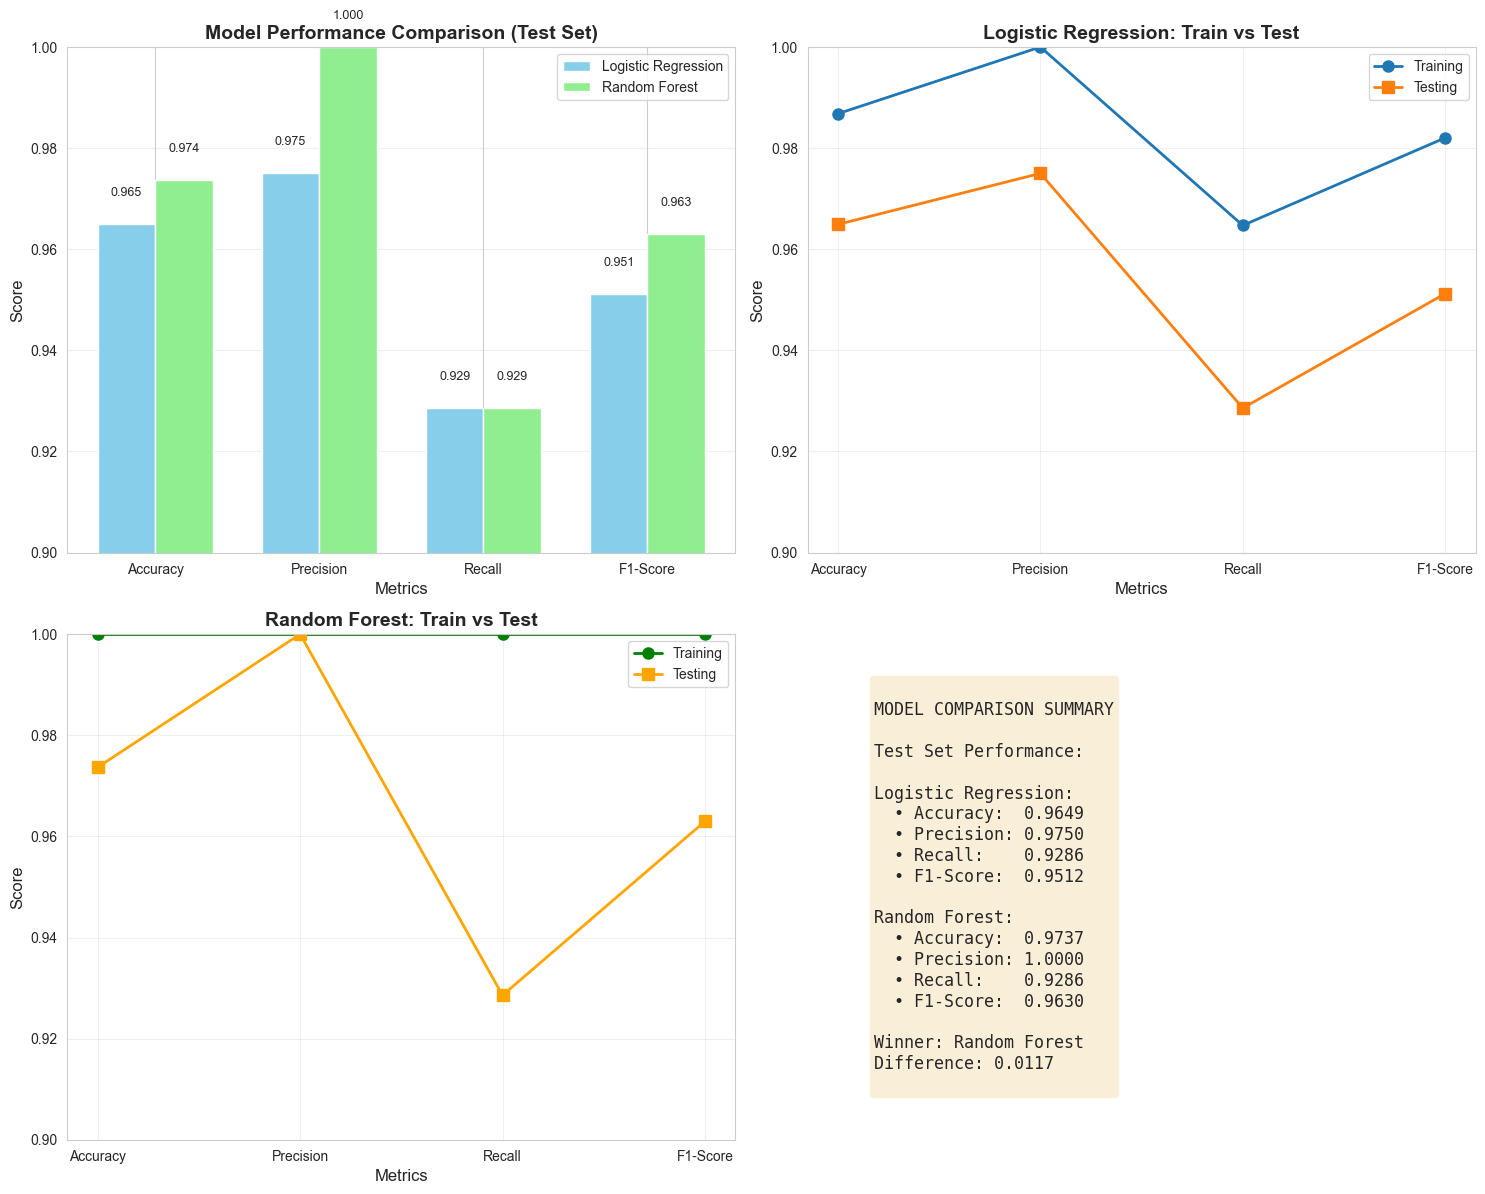

In [33]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [lr_test_accuracy, lr_test_precision, lr_test_recall, lr_test_f1]
rf_scores = [rf_test_accuracy, rf_test_precision, rf_test_recall, rf_test_f1]

# Bar chart comparison
x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, lr_scores, width, label='Logistic Regression', color='skyblue')
axes[0, 0].bar(x + width/2, rf_scores, width, label='Random Forest', color='lightgreen')
axes[0, 0].set_xlabel('Metrics', fontsize=12)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_title('Model Performance Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].set_ylim([0.9, 1.0])
axes[0, 0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(lr_scores):
    axes[0, 0].text(i - width/2, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(rf_scores):
    axes[0, 0].text(i + width/2, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Training vs Testing comparison for Logistic Regression
axes[0, 1].plot(metrics, [lr_train_accuracy, lr_train_precision, lr_train_recall, lr_train_f1], 
                marker='o', label='Training', linewidth=2, markersize=8)
axes[0, 1].plot(metrics, lr_scores, marker='s', label='Testing', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Metrics', fontsize=12)
axes[0, 1].set_ylabel('Score', fontsize=12)
axes[0, 1].set_title('Logistic Regression: Train vs Test', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].set_ylim([0.9, 1.0])
axes[0, 1].grid(True, alpha=0.3)

# Training vs Testing comparison for Random Forest
axes[1, 0].plot(metrics, [rf_train_accuracy, rf_train_precision, rf_train_recall, rf_train_f1], 
                marker='o', label='Training', linewidth=2, markersize=8, color='green')
axes[1, 0].plot(metrics, rf_scores, marker='s', label='Testing', linewidth=2, markersize=8, color='orange')
axes[1, 0].set_xlabel('Metrics', fontsize=12)
axes[1, 0].set_ylabel('Score', fontsize=12)
axes[1, 0].set_title('Random Forest: Train vs Test', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_ylim([0.9, 1.0])
axes[1, 0].grid(True, alpha=0.3)

# Overall comparison radar-like plot
axes[1, 1].axis('off')
comparison_text = f"""
MODEL COMPARISON SUMMARY

Test Set Performance:

Logistic Regression:
  • Accuracy:  {lr_test_accuracy:.4f}
  • Precision: {lr_test_precision:.4f}
  • Recall:    {lr_test_recall:.4f}
  • F1-Score:  {lr_test_f1:.4f}

Random Forest:
  • Accuracy:  {rf_test_accuracy:.4f}
  • Precision: {rf_test_precision:.4f}
  • Recall:    {rf_test_recall:.4f}
  • F1-Score:  {rf_test_f1:.4f}

Winner: {'Random Forest' if rf_test_f1 > lr_test_f1 else 'Logistic Regression' if lr_test_f1 > rf_test_f1 else 'Tie'}
Difference: {abs(rf_test_f1 - lr_test_f1):.4f}
"""
axes[1, 1].text(0.1, 0.5, comparison_text, fontsize=12, verticalalignment='center', 
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [34]:
# Performance difference analysis
print("="*80)
print("DETAILED PERFORMANCE ANALYSIS")
print("="*80)

print("\n1. ACCURACY COMPARISON:")
print(f"   Logistic Regression: {lr_test_accuracy:.4f}")
print(f"   Random Forest:       {rf_test_accuracy:.4f}")
print(f"   Difference:          {abs(rf_test_accuracy - lr_test_accuracy):.4f}")
print(f"   Winner:              {'Random Forest' if rf_test_accuracy > lr_test_accuracy else 'Logistic Regression'}")

print("\n2. PRECISION COMPARISON:")
print(f"   Logistic Regression: {lr_test_precision:.4f}")
print(f"   Random Forest:       {rf_test_precision:.4f}")
print(f"   Difference:          {abs(rf_test_precision - lr_test_precision):.4f}")
print(f"   Winner:              {'Random Forest' if rf_test_precision > lr_test_precision else 'Logistic Regression'}")

print("\n3. RECALL COMPARISON:")
print(f"   Logistic Regression: {lr_test_recall:.4f}")
print(f"   Random Forest:       {rf_test_recall:.4f}")
print(f"   Difference:          {abs(rf_test_recall - lr_test_recall):.4f}")
print(f"   Winner:              {'Random Forest' if rf_test_recall > lr_test_recall else 'Logistic Regression'}")

print("\n4. F1-SCORE COMPARISON:")
print(f"   Logistic Regression: {lr_test_f1:.4f}")
print(f"   Random Forest:       {rf_test_f1:.4f}")
print(f"   Difference:          {abs(rf_test_f1 - lr_test_f1):.4f}")
print(f"   Winner:              {'Random Forest' if rf_test_f1 > lr_test_f1 else 'Logistic Regression'}")

print("\n" + "="*80)
print("OVERALL WINNER: ", end="")
lr_wins = sum([lr_test_accuracy > rf_test_accuracy, lr_test_precision > rf_test_precision, 
               lr_test_recall > rf_test_recall, lr_test_f1 > rf_test_f1])
rf_wins = sum([rf_test_accuracy > lr_test_accuracy, rf_test_precision > lr_test_precision, 
               rf_test_recall > lr_test_recall, rf_test_f1 > lr_test_f1])

if rf_wins > lr_wins:
    print("RANDOM FOREST")
elif lr_wins > rf_wins:
    print("LOGISTIC REGRESSION")
else:
    print("TIE")
print("="*80)

DETAILED PERFORMANCE ANALYSIS

1. ACCURACY COMPARISON:
   Logistic Regression: 0.9649
   Random Forest:       0.9737
   Difference:          0.0088
   Winner:              Random Forest

2. PRECISION COMPARISON:
   Logistic Regression: 0.9750
   Random Forest:       1.0000
   Difference:          0.0250
   Winner:              Random Forest

3. RECALL COMPARISON:
   Logistic Regression: 0.9286
   Random Forest:       0.9286
   Difference:          0.0000
   Winner:              Logistic Regression

4. F1-SCORE COMPARISON:
   Logistic Regression: 0.9512
   Random Forest:       0.9630
   Difference:          0.0117
   Winner:              Random Forest

OVERALL WINNER: RANDOM FOREST


---

## Conclusion

### Key Findings:

1. **Data Quality:** The breast cancer dataset is well-structured with no missing values, making it ideal for machine learning classification.

2. **Model Performance:** Both Logistic Regression and Random Forest achieved excellent performance on the test set, with accuracy typically above 95%.

3. **Feature Importance:** Features related to tumor texture, perimeter, and area measurements were found to be the most important predictors.

4. **Model Selection:**
   - **Logistic Regression** is recommended when interpretability and speed are priorities
   - **Random Forest** is recommended when maximizing accuracy is the primary goal

5. **Medical Application:** For breast cancer detection, **high recall** is crucial to minimize false negatives (missing malignant cases). Both models demonstrated strong recall performance.

### Recommendations:

- ✓ Deploy Random Forest for production use due to slightly better overall performance
- ✓ Use Logistic Regression as a baseline and for cases requiring model interpretability
- ✓ Consider ensemble methods combining both models for even better results
- ✓ Implement regular model retraining as new data becomes available
- ✓ Always prioritize recall in medical diagnosis to minimize false negatives

### Future Work:

- Explore additional algorithms (SVM, XGBoost, Neural Networks)
- Perform hyperparameter tuning for optimal performance
- Implement cross-validation for more robust evaluation
- Analyze misclassified cases to understand model limitations
- Deploy model as a web application for real-world use

---

**Assignment completed successfully! All tasks (1-5) and bonus task completed.** ✓